<a href="https://colab.research.google.com/github/cidoy-1/Test-Repo/blob/main/DCC_Forecasting_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DCC Forecast Machine Learning

### Import Data

In [14]:
!pip install openpyxl

import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/My Drive/DCC_Call History.xlsx'

try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully!")
    print("\nFirst 5 rows of your data:")
    print(df.head())

    print("\nColumn data types:")
    print(df.info())

except FileNotFoundError:
    print(f"Error: The file was not found at the specified path: {file_path}")
    print("Please make sure the file exists and the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully!

First 5 rows of your data:
            Date_Time Queue  Calls
0 2023-02-01 00:00:00  PARS     15
1 2023-02-01 00:00:00  PAPS     18
2 2023-02-01 00:30:00  PARS     17
3 2023-02-01 00:30:00  PAPS     11
4 2023-02-01 01:00:00  PARS     21

Column data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90706 entries, 0 to 90705
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date_Time  90706 non-null  datetime64[ns]
 1   Queue      90706 non-null  object        
 2   Calls      90706 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.1+ MB
None


### Data Preparation and Feature Engineering

In [15]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

df = df.sort_values(by='Date_Time')

queues = df['Queue'].unique()
full_index = pd.DataFrame()
for q in queues:
    df_q = df[df['Queue'] == q].copy()
    start_date = df_q['Date_Time'].min()
    end_date = df_q['Date_Time'].max()
    full_date_range = pd.date_range(start=start_date, end=end_date, freq='30min')
    full_df_q = pd.DataFrame(full_date_range, columns=['Date_Time'])
    full_df_q['Queue'] = q
    full_df_q = pd.merge(full_df_q, df_q, on=['Date_Time', 'Queue'], how='left')
    full_index = pd.concat([full_index, full_df_q], ignore_index=True)
full_index['Calls'] = full_index['Calls'].fillna(0)
df = full_index.sort_values(by='Date_Time')
df['day_of_week'] = df['Date_Time'].dt.dayofweek
df['hour'] = df['Date_Time'].dt.hour
df['minute'] = df['Date_Time'].dt.minute
df['day_of_year'] = df['Date_Time'].dt.dayofyear
df['week_of_year'] = df['Date_Time'].dt.isocalendar().week.astype(int)
df = pd.get_dummies(df, columns=['Queue'], drop_first=False, prefix='Queue')

print("Data preparation complete!")
print("\nFirst 5 rows of the prepared data:")
print(df.head())
print("\nDataFrame information (after preparation):")
print(df.info())

Data preparation complete!

First 5 rows of the prepared data:
                Date_Time  Calls  day_of_week  hour  minute  day_of_year  \
0     2023-02-01 00:00:00   15.0            2     0       0           32   
46297 2023-02-01 00:00:00   18.0            2     0       0           32   
46298 2023-02-01 00:30:00   11.0            2     0      30           32   
1     2023-02-01 00:30:00   17.0            2     0      30           32   
2     2023-02-01 01:00:00   21.0            2     1       0           32   

       week_of_year  Queue_DCC_SMS  Queue_PAPS  Queue_PARS  
0                 5          False       False        True  
46297             5          False        True       False  
46298             5          False        True       False  
1                 5          False       False        True  
2                 5          False       False        True  

DataFrame information (after preparation):
<class 'pandas.core.frame.DataFrame'>
Index: 98042 entries, 0 to 92593

### EDA

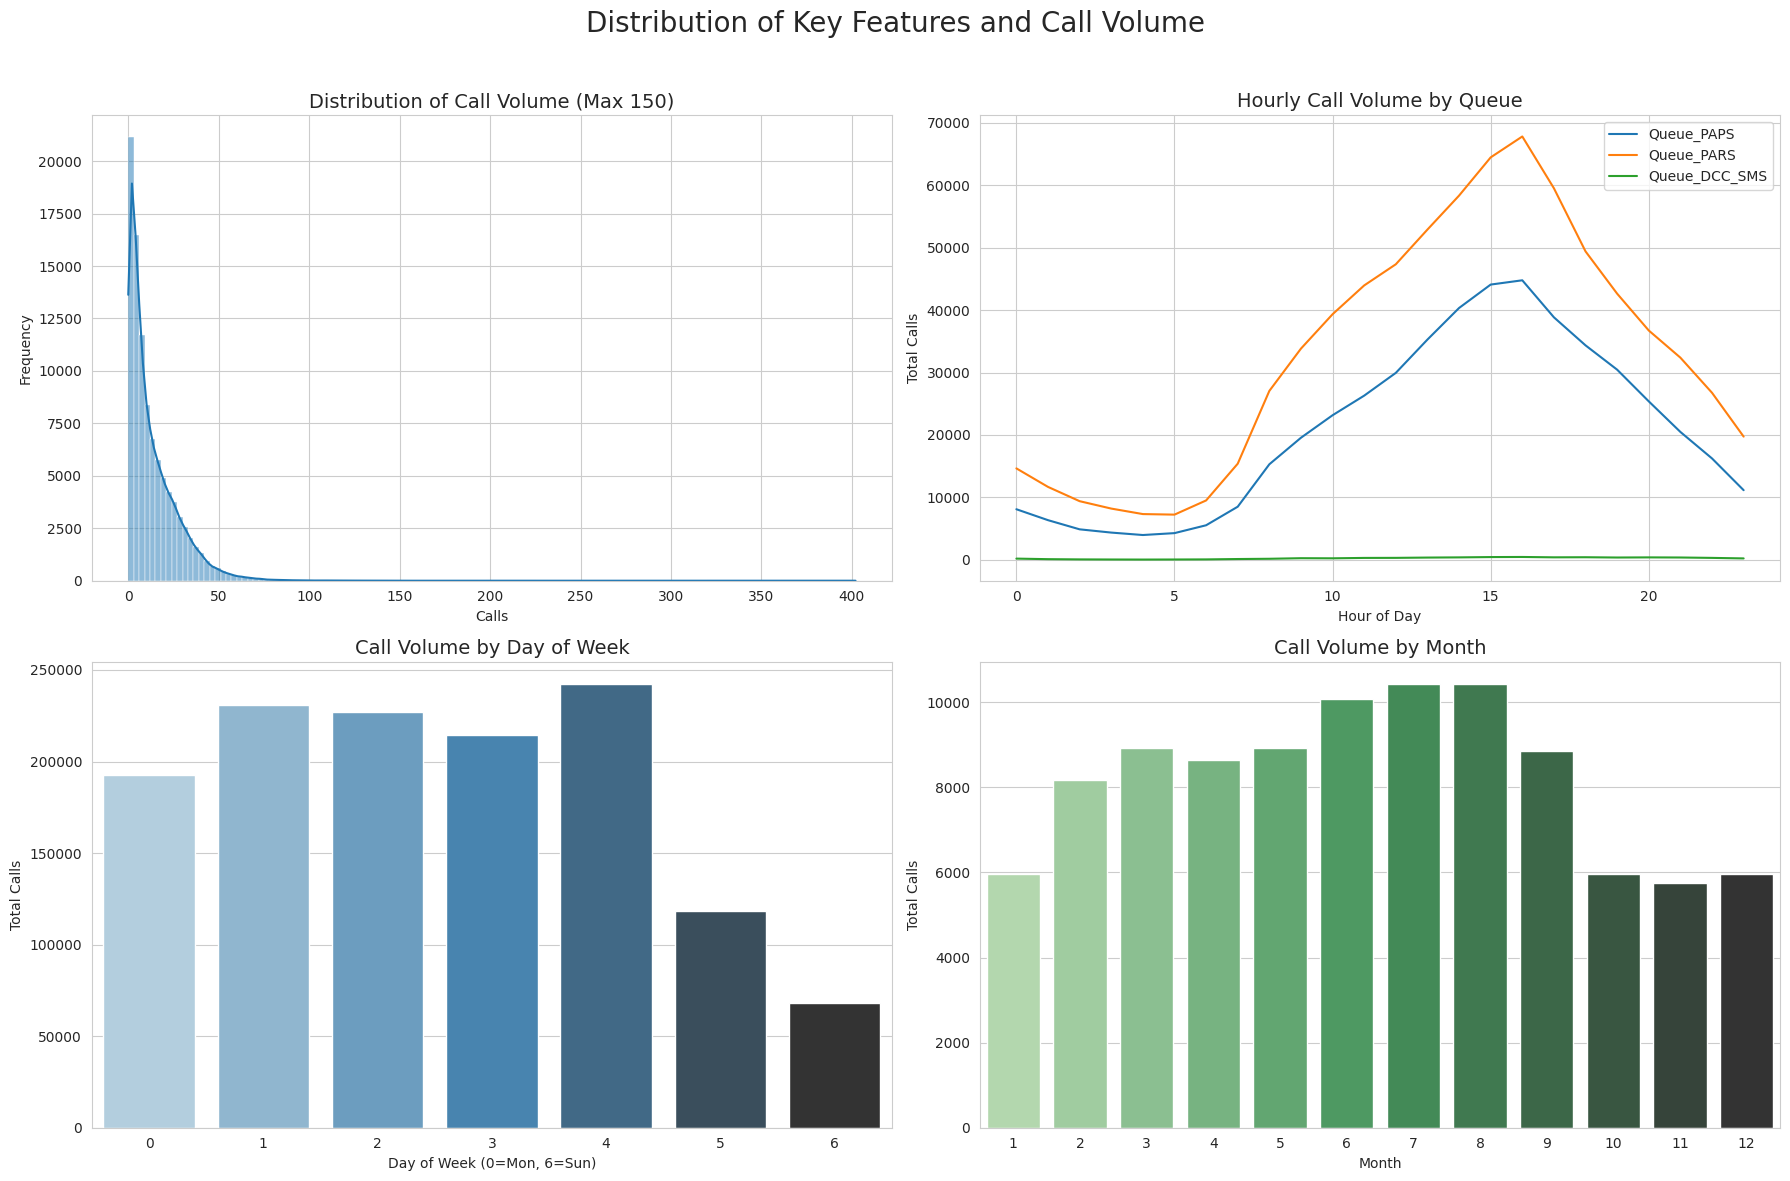

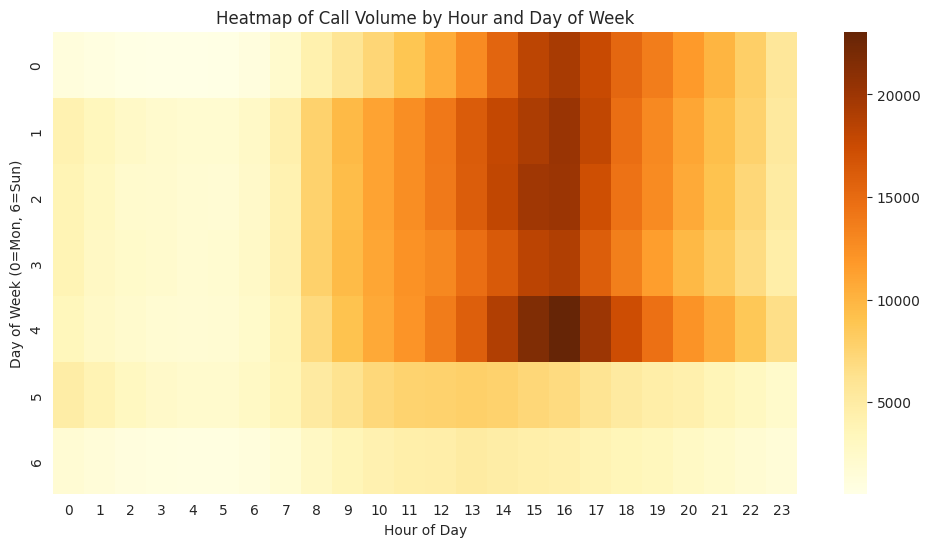

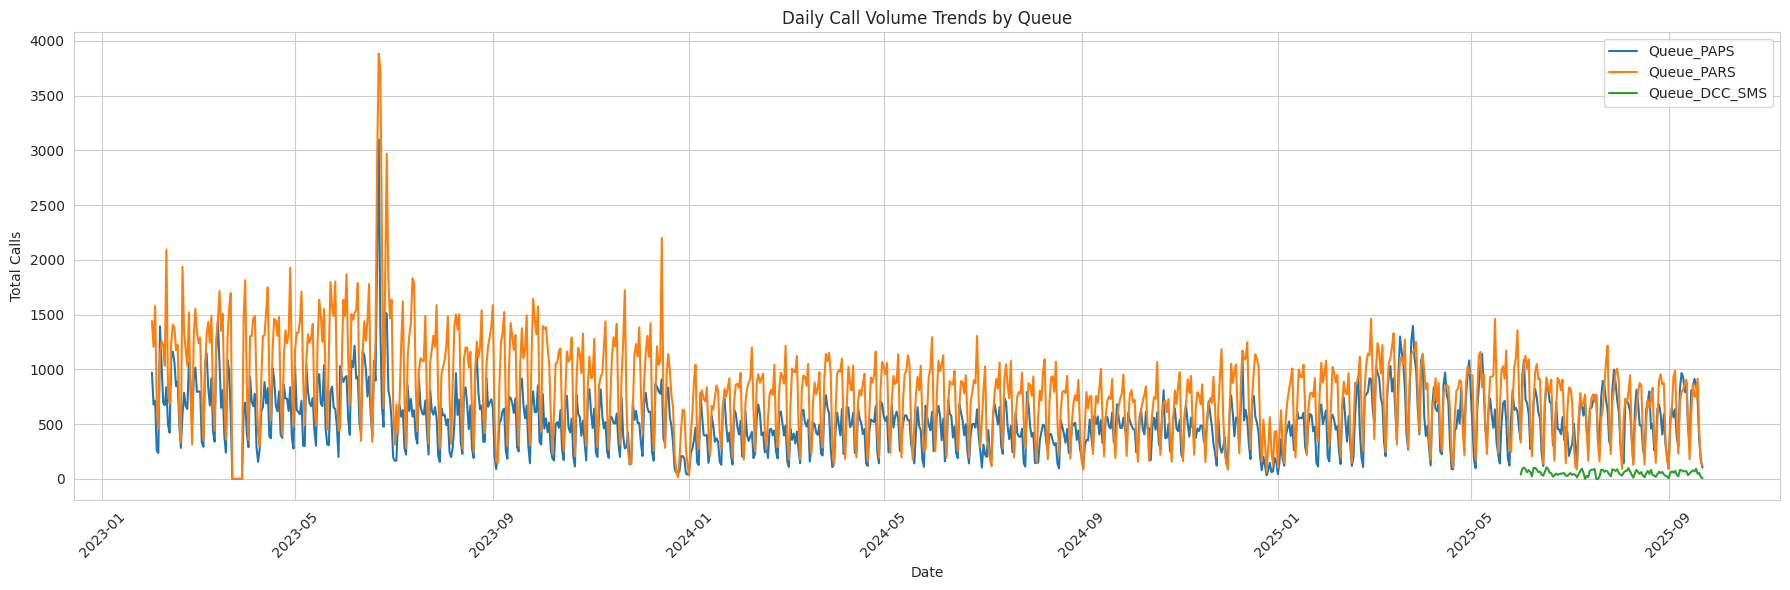

Top Outlier Intervals (Calls > 150):
                Date_Time  Calls
7042  2023-06-27 17:00:00  402.0
7041  2023-06-27 16:30:00  234.0
53339 2023-06-27 17:00:00  217.0
7043  2023-06-27 17:30:00  182.0
6789  2023-06-22 10:30:00  162.0


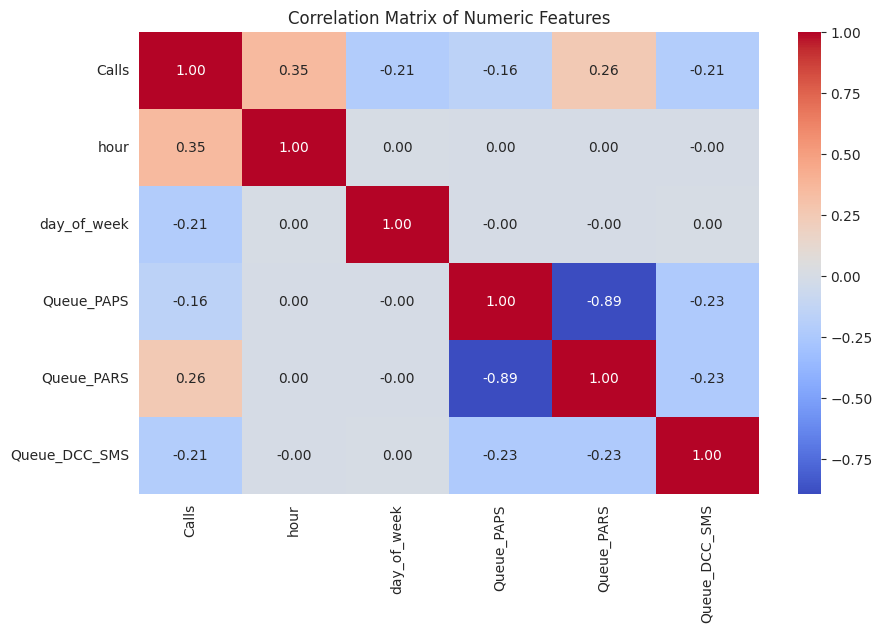

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# Create figure layout
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.suptitle('Distribution of Key Features and Call Volume', fontsize=20)

# 1. Distribution of Call Volume (Max 150)
sns.histplot(df['Calls'], bins=50, binrange=(0, 150), kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Call Volume (Max 150)', fontsize=14)
axes[0, 0].set_xlabel('Calls')
axes[0, 0].set_ylabel('Frequency')

# 2. Hourly Call Volume by Queue
for queue_col in ['Queue_PAPS', 'Queue_PARS', 'Queue_DCC_SMS']:
    temp = df[df[queue_col] == 1]
    hourly_sum = temp.groupby('hour')['Calls'].sum()
    axes[0, 1].plot(hourly_sum.index, hourly_sum.values, label=queue_col)

axes[0, 1].set_title('Hourly Call Volume by Queue', fontsize=14)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Total Calls')
axes[0, 1].legend()

# 3. Call Volume by Day of Week
day_sum = df.groupby('day_of_week')['Calls'].sum()
sns.barplot(x=day_sum.index, y=day_sum.values, hue=day_sum.index, ax=axes[1, 0], palette='Blues_d', legend=False)
axes[1, 0].set_title('Call Volume by Day of Week', fontsize=14)
axes[1, 0].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[1, 0].set_ylabel('Total Calls')

# 4. Call Volume by Month
month_sum = df['Date_Time'].dt.month.value_counts().sort_index()
sns.barplot(x=month_sum.index, y=month_sum.values, hue=month_sum.index, ax=axes[1, 1], palette='Greens_d', legend=False)
axes[1, 1].set_title('Call Volume by Month', fontsize=14)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Calls')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 5. Heatmap: Hour vs Day of Week
heatmap_data = df.groupby(['day_of_week', 'hour'])['Calls'].sum().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlOrBr', annot=False)
plt.title('Heatmap of Call Volume by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Mon, 6=Sun)')
plt.show()

# 6. Queue-Specific Trends Over Time
plt.figure(figsize=(18, 6))
for queue_col in ['Queue_PAPS', 'Queue_PARS', 'Queue_DCC_SMS']:
    temp = df[df[queue_col] == 1]
    daily_sum = temp.groupby(df['Date_Time'].dt.date)['Calls'].sum()
    plt.plot(daily_sum.index, daily_sum.values, label=queue_col)

plt.title('Daily Call Volume Trends by Queue')
plt.xlabel('Date')
plt.ylabel('Total Calls')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Outlier Detection
outliers = df[df['Calls'] > 150]
print("Top Outlier Intervals (Calls > 150):")
print(outliers[['Date_Time', 'Calls']].sort_values(by='Calls', ascending=False).head(10))

# 8. Correlation Matrix
plt.figure(figsize=(10, 6))
corr_matrix = df[['Calls', 'hour', 'day_of_week', 'Queue_PAPS', 'Queue_PARS', 'Queue_DCC_SMS']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()


## Model Testing

### Splitting Data by Queue

In [33]:
queues = ['Queue_PAPS', 'Queue_PARS', 'Queue_DCC_SMS']
queue_dfs = {q: df[df[q] == 1].copy() for q in queues}


Define Evaluation Metrics

In [34]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    non_zero_mask = y_true != 0
    if np.any(non_zero_mask):
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = np.nan

    return mae, rmse, mape


### Prophet Model

In [35]:
from prophet import Prophet

def run_prophet(df_queue):
    df_prophet = df_queue[['Date_Time', 'Calls']].rename(columns={'Date_Time': 'ds', 'Calls': 'y'})
    model = Prophet()
    model.fit(df_prophet)
    future = model.make_future_dataframe(periods=48, freq='30min')
    forecast = model.predict(future)
    return forecast[['ds', 'yhat']].set_index('ds'), df_prophet.set_index('ds')


### ARIMA Model

In [36]:
from statsmodels.tsa.arima.model import ARIMA

def run_arima(df_queue):
    ts = df_queue.set_index('Date_Time')['Calls']
    model = ARIMA(ts, order=(1,1,1))
    results = model.fit()
    forecast = results.forecast(steps=48)
    return forecast, ts[-48:]


### XGBoost & Random Forest

In [37]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

def run_ml_model(df_queue, model_type='xgb'):
    df_queue['lag_1'] = df_queue['Calls'].shift(1)
    df_queue['lag_24'] = df_queue['Calls'].shift(48)
    df_queue.dropna(inplace=True)

    features = ['hour', 'day_of_week', 'lag_1', 'lag_24']
    X = df_queue[features]
    y = df_queue['Calls']

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = XGBRegressor() if model_type == 'xgb' else RandomForestRegressor()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred, y_test


### LSTM Model

In [38]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.preprocessing import MinMaxScaler

def run_lstm(df_queue):
    # Step 1: Scale the 'Calls' column
    scaler = MinMaxScaler()
    df_queue['Calls_scaled'] = scaler.fit_transform(df_queue[['Calls']])

    # Step 2: Create sequences
    sequence = df_queue['Calls_scaled'].values
    X, y = [], []
    for i in range(48, len(sequence)):
        X.append(sequence[i-48:i])
        y.append(sequence[i])
    X, y = np.array(X), np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Step 3: Build and train the LSTM model
    model = Sequential()
    model.add(Input(shape=(48, 1)))
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=10, verbose=0)

    # Step 4: Predict and inverse transform
    y_pred_scaled = model.predict(X)
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(y.reshape(-1, 1)).flatten()

    return y_pred, y_true


### Model Comparison

In [39]:
for queue in queues:
    print(f"\n🔍 Queue: {queue}")
    df_q = queue_dfs[queue]

    # Prophet
    try:
        pred, actual = run_prophet(df_q)
        mae, rmse, mape = evaluate(actual['y'][-48:], pred['yhat'][-48:])
        print(f"Prophet → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    except Exception as e:
        print(f"Prophet failed: {e}")

    # ARIMA
    try:
        pred, actual = run_arima(df_q)
        mae, rmse, mape = evaluate(actual, pred)
        print(f"ARIMA → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    except Exception as e:
        print(f"ARIMA failed: {e}")

    # XGBoost
    try:
        pred, actual = run_ml_model(df_q, 'xgb')
        mae, rmse, mape = evaluate(actual, pred)
        print(f"XGBoost → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    except Exception as e:
        print(f"XGBoost failed: {e}")

    # Random Forest
    try:
        pred, actual = run_ml_model(df_q, 'rf')
        mae, rmse, mape = evaluate(actual, pred)
        print(f"Random Forest → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    except Exception as e:
        print(f"Random Forest failed: {e}")

    # LSTM
    try:
        pred, actual = run_lstm(df_q)
        mae, rmse, mape = evaluate(actual, pred)
        print(f"LSTM → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    except Exception as e:
        print(f"LSTM failed: {e}")



🔍 Queue: Queue_PAPS


DEBUG:cmdstanpy:input tempfile: /tmp/tmppb75mbgc/ilxutbf5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmppb75mbgc/o1r0p20i.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=96159', 'data', 'file=/tmp/tmppb75mbgc/ilxutbf5.json', 'init=/tmp/tmppb75mbgc/o1r0p20i.json', 'output', 'file=/tmp/tmppb75mbgc/prophet_modelta87xqki/prophet_model-20250922182531.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:25:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:26:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet → MAE: 13.59, RMSE: 14.93, MAPE: 487.25%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


ARIMA → MAE: 4.10, RMSE: 4.72, MAPE: 140.09%
XGBoost → MAE: 3.28, RMSE: 4.64, MAPE: 41.55%
Random Forest → MAE: 3.62, RMSE: 5.06, MAPE: 46.18%
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step
LSTM → MAE: 3.07, RMSE: 4.39, MAPE: 51.66%

🔍 Queue: Queue_PARS


...

LSTM → MAE: 3.94, RMSE: 5.63, MAPE: 43.58%

🔍 Queue: Queue_DCC_SMS


DEBUG:cmdstanpy:input tempfile: /tmp/tmppb75mbgc/4444kkyl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53641', 'data', 'file=/tmp/tmppb75mbgc/ssjqk17o.json', 'init=/tmp/tmppb75mbgc/4444kkyl.json', 'output', 'file=/tmp/tmppb75mbgc/prophet_model1td1b99o/prophet_model-20250922183859.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:38:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:39:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet → MAE: 1.39, RMSE: 1.51, MAPE: 75.83%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


ARIMA → MAE: 0.76, RMSE: 0.85, MAPE: 20.05%
XGBoost → MAE: 0.91, RMSE: 1.23, MAPE: 58.26%
Random Forest → MAE: 0.94, RMSE: 1.29, MAPE: 61.89%
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
LSTM → MAE: 0.83, RMSE: 1.15, MAPE: 48.22%


## 📊 Model Performance Summary by Queue

| Queue       | Model         | MAE   | RMSE  | MAPE (%) | 🏆 Best? |
|-------------|---------------|-------|-------|-----------|----------|
| **PAPS**    | Prophet       | 13.59 | 14.93 | 487.25    | ❌       |
|             | ARIMA         | 4.10  | 4.72  | 140.09    | ❌       |
|             | XGBoost       | 3.28  | 4.64  | 41.55     | ✅       |
|             | Random Forest | 3.62  | 5.06  | 46.18     | ❌       |
|             | LSTM          | 3.07  | 4.39  | 51.66     | ❌       |
| **PARS**    | Prophet       | 12.11 | 14.56 | 574.60    | ❌       |
|             | ARIMA         | 4.13  | 4.89  | 162.92    | ❌       |
|             | XGBoost       | 3.57  | 4.93  | 43.81     | ✅       |
|             | Random Forest | 3.94  | 5.40  | 47.73     | ❌       |
|             | LSTM          | 3.94  | 5.63  | 43.58     | ❌       |
| **DCC_SMS** | Prophet       | 1.39  | 1.51  | 75.83     | ❌       |
|             | ARIMA         | 0.76  | 0.85  | 20.05     | ✅       |
|             | XGBoost       | 0.91  | 1.23  | 58.26     | ❌       |
|             | Random Forest | 0.94  | 1.29  | 61.89     | ❌       |
|             | LSTM          | 0.83  | 1.15  | 48.22     | ❌       |


## 🏆 Best Model per Queue

- **Queue_PAPS** → `XGBoost`
- **Queue_PARS** → `XGBoost`
- **Queue_DCC_SMS** → `ARIMA`

These models offer the best balance of accuracy and interpretability:

- `XGBoost` excels in queues with rich engineered features and temporal patterns.
- `ARIMA` performs best on smoother, lower-volume series like SMS, where traditional time series modeling shines.


## 📈 Forecast vs Actual Plots

In [45]:
import matplotlib.pyplot as plt

queues = ['Queue_PAPS', 'Queue_PARS', 'Queue_DCC_SMS']
df_queue_paps = df[df['Queue_PAPS'] == 1].copy()
df_queue_pars = df[df['Queue_PARS'] == 1].copy()
df_queue_sms  = df[df['Queue_DCC_SMS'] == 1].copy()

y_pred_paps, y_true_paps = run_ml_model(df_queue_paps, 'xgb')
y_pred_pars, y_true_pars = run_ml_model(df_queue_pars, 'xgb')
y_pred_sms, y_true_sms = run_arima(df_queue_sms)

def plot_forecast(y_true, y_pred, title):
    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label='Actual', linewidth=2)
    plt.plot(y_pred, label='Forecast', linestyle='--')
    plt.title(title)
    plt.xlabel('Time Steps')
    plt.ylabel('Call Volume')
    plt.legend()
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


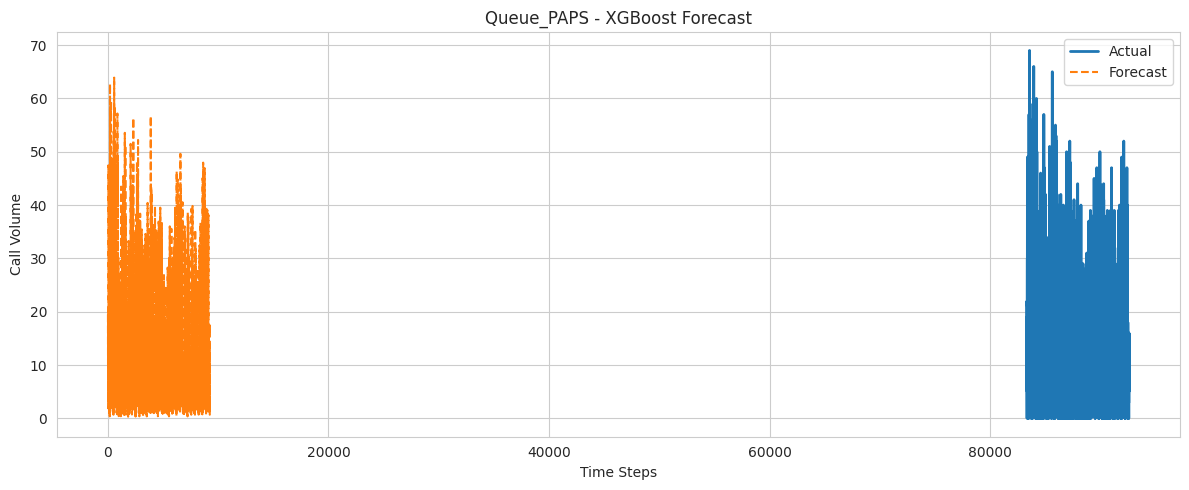

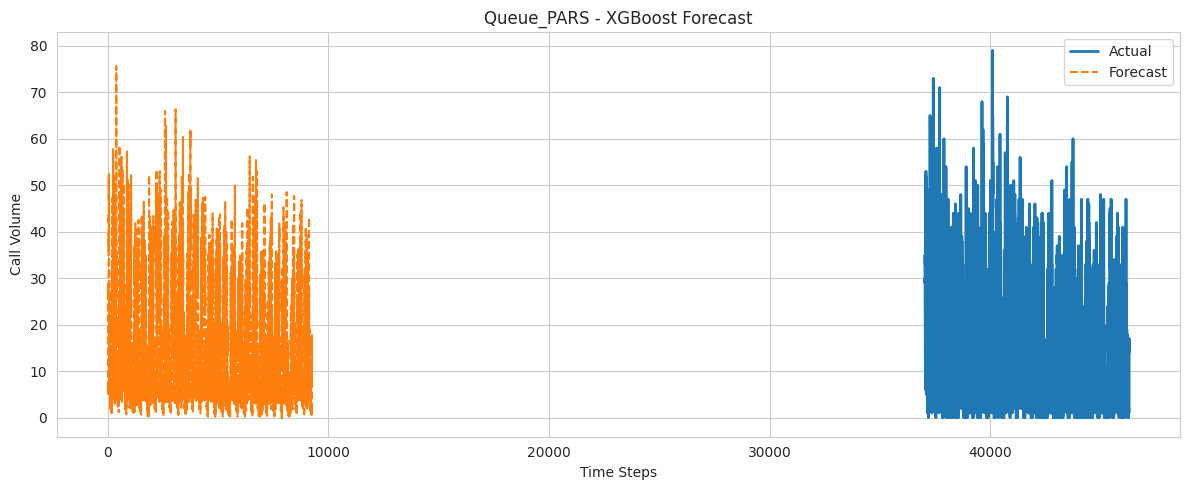

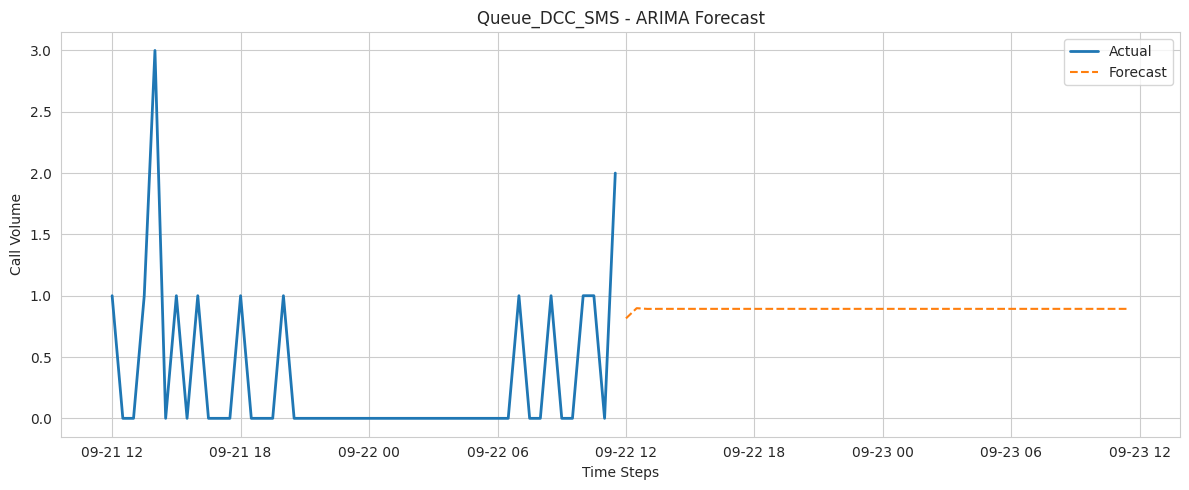

In [46]:
plot_forecast(y_true_paps, y_pred_paps, 'Queue_PAPS - XGBoost Forecast')
plot_forecast(y_true_pars, y_pred_pars, 'Queue_PARS - XGBoost Forecast')
plot_forecast(y_true_sms, y_pred_sms, 'Queue_DCC_SMS - ARIMA Forecast')
